<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE--SUPERVISADO/blob/main/CLASE_5_Regresion_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión logística

**¿Qué problema resuelve?**

- La regresión logística predice la probabilidad de que ocurra un evento binario (sí/no, 1/0).
- Ejemplos: ¿el cliente compra? ¿el paciente tiene la enfermedad? ¿el email es spam?


**La idea del modelo**

- Primero calcula un puntaje lineal (como en regresión lineal):

$$
z = \beta_{0} + \beta_{1}x_{1} + \beta_{2}x_{2} + \cdots + \beta_{p}x_{p}
$$

- Luego transforma ese z en probabilidad con la función sigmoide:

$$
\hat{p} = \frac{1}{1 + e^{-z}}
$$

- Así $\hat{p}$ siempre queda entre 0 y 1.


**Regla de decisión**

- Con la probabilidad $\hat{p}$
  - Si $\hat{p}≥0.5$ ⇒ predice 1 (predice que el evento si ocurre).
  - Si $\hat{p}<0.5$ ⇒ predice 0 (predice que el evento no ocurre)

- El umbral 0.5 se puede mover según el costo de errores.

**Cómo ajusta los β?**

- No minimiza MSE; maximiza la verosimilitud (equivale a minimizar log-loss).
- Se resuelve numéricamente (p. ej., descenso por gradiente).
- Opcionalmente se agrega regularización (L1/L2) para evitar sobreajuste.

**Cómo se interpretan los coeficientes**

- Si \( \beta_j > 0 \) ⇒ al aumentar \( x_j \), aumenta \( \hat{p} \).  
- Si \( \beta_j < 0 \) ⇒ al aumentar \( x_j \), disminuye \( \hat{p} \).  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
path= '/content/drive/MyDrive/APREN. SUPERVISADO/bankloan.csv'
df= pd.read_csv(path)

In [ ]:
df.head()

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


# Modelo de regresión logística con `sklearn`

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler


X = df.drop(['Personal.Loan','ID'], axis=1)
y = df['Personal.Loan']

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Datos escalados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo de regresion logistica
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train_scaled, y_train)

# Prediccion en el set de prueba
y_pred = model.predict(X_test_scaled)

# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.955

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       895
           1       0.87      0.68      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.87      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix:
[[884  11]
 [ 34  71]]


In [ ]:
# Get the intercept and coefficients from the trained model
intercept = model.intercept_[0]
coefficients = model.coef_[0]

print(f"Intercept (β0): {intercept:.4f}")
print("\nCoefficients (βi):")
# Assuming X_train_scaled is a numpy array, get feature names from original X_train
feature_names = X_train.columns

for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.4f}")

print("\nThe logistic regression equation (in terms of log-odds) is:")
print(f"ln(P(Personal.Loan=1) / (1 - P(Personal.Loan=1))) = {intercept:.4f} + ", end="")

for i, (feature, coef) in enumerate(zip(feature_names, coefficients)):
    if i > 0:
        print(" + ", end="")
    print(f"({coef:.4f} * {feature})", end="")

print()

Intercept (β0): -4.5701

Coefficients (βi):
Age: -0.2694
Experience: 0.3934
Income: 2.3944
ZIP.Code: -0.0891
Family: 0.8168
CCAvg: 0.1881
Education: 1.3354
Mortgage: 0.0549
Securities.Account: -0.2708
CD.Account: 0.8975
Online: -0.3028
CreditCard: -0.5580

The logistic regression equation (in terms of log-odds) is:
ln(P(Personal.Loan=1) / (1 - P(Personal.Loan=1))) = -4.5701 + (-0.2694 * Age) + (0.3934 * Experience) + (2.3944 * Income) + (-0.0891 * ZIP.Code) + (0.8168 * Family) + (0.1881 * CCAvg) + (1.3354 * Education) + (0.0549 * Mortgage) + (-0.2708 * Securities.Account) + (0.8975 * CD.Account) + (-0.3028 * Online) + (-0.5580 * CreditCard)


## Como opera el modelo clasificando un registro

Registro (el primero en X_test):
Age                      30.0
Experience                4.0
Income                   35.0
ZIP.Code              92130.0
Family                    2.0
CCAvg                     0.3
Education                 2.0
Mortgage                  0.0
Securities.Account        1.0
CD.Account                0.0
Online                    0.0
CreditCard                1.0
Name: 1501, dtype: float64

Actual class for this record: 0

Paso 1: Calcular el z-value (linear combination): -8.5344
Paso 2: Calcular la probabilidad de Personal.Loan=1: 0.0002
Paso 3: Clasificación con un threshold (0.5): 0
Result: El modelo predice No Personal.Loan.


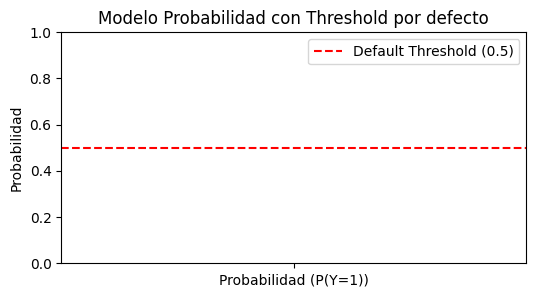

In [ ]:
sample_record_scaled = X_test_scaled[0, :]
sample_record_original = X_test.iloc[0, :]
actual_class = y_test.iloc[0]

print(f"Registro (el primero en X_test):")
print(sample_record_original)
print(f"\nActual class for this record: {actual_class}")

# Paso 1: Calcular la combinación lineal (z-value)
# z = β0 + β1*x1 + β2*x2 + ... + βn*xn
z = intercept + np.sum(coefficients * sample_record_scaled)

print(f"\nPaso 1: Calcular el z-value (linear combination): {z:.4f}")

# Paso 2: Calcular la probabilidad usando la función logística
# P(Y=1|X) = 1 / (1 + e^(-z))
probability = 1 / (1 + np.exp(-z))

print(f"Paso 2: Calcular la probabilidad de Personal.Loan=1: {probability:.4f}")

# Step 3: Calcular basado en el threshold (por defecto es 0.5)
predicted_class = 1 if probability >= 0.5 else 0

print(f"Paso 3: Clasificación con un threshold (0.5): {predicted_class}")
print(f"Result: El modelo predice {'Personal.Loan' if predicted_class == 1 else 'No Personal.Loan'}.")


plt.figure(figsize=(6, 3))
plt.bar(['Probabilidad (P(Y=1))'], [probability], color='skyblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.ylim(0, 1)
plt.ylabel('Probabilidad')
plt.title('Modelo Probabilidad con Threshold por defecto')
plt.legend()
plt.show()



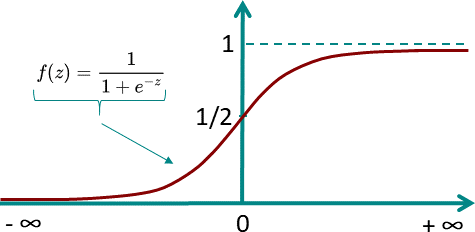

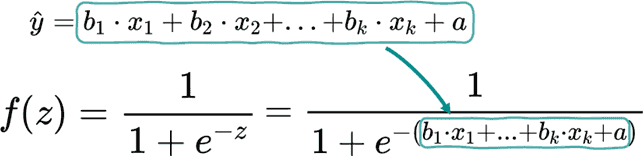

In [ ]:
# Evaluacion del modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

Accuracy: 0.955

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       895
           1       0.87      0.68      0.76       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.87      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix:
[[884  11]
 [ 34  71]]


## Interpretación de la Matriz de Confusión:


|                   | Predicción Negativo | Predicción Positivo |
|-------------------|---------------------|---------------------|
| **Real Negativo** | Verdaderos negativos| Falsos positivos    |
| **Real Positivo** | Falsos negativos    | Verdaderos positivos|



- La matriz de confusión muestra el número de predicciones correctas e incorrectas realizadas por el clasificador en comparación con los resultados reales.
- Verdaderos Negativos (arriba-izquierda): Casos negativos predichos correctamente.
- Falsos Positivos (arriba-derecha): Casos negativos clasificados incorrectamente como positivos (Error Tipo I).
- Falsos Negativos (abajo-izquierda): Casos positivos clasificados incorrectamente como negativos (Error Tipo II).
- Verdaderos Positivos (abajo-derecha): Casos positivos predichos correctamente.


## Interpretación del Reporte de clasificación:

- Precisión (Precision): La capacidad del clasificador de no etiquetar como positivo a una muestra que en realidad es negativa.
- Exhaustividad o Sensibilidad (Recall): La capacidad del clasificador de encontrar todas las muestras positivas.
- F1-score: Una media armónica ponderada entre la precisión y la exhaustividad; el valor óptimo es 1 y el peor valor es 0.
- Soporte (Support): El número de ocurrencias de cada clase en los datos de prueba (y_test).
- Exactitud (Accuracy): La proporción de predicciones correctas entre el total de casos analizados.



**Precisión**

La capacidad del clasificador de no etiquetar como positivo a una muestra que en realidad es negativa.

- Indica qué tan confiables son las predicciones positivas del modelo.
- Un valor cercano a 1.0 (o 100%) significa que casi nunca se etiquetan como positivas muestras que en realidad son negativas.
- Conviene priorizarla cuando los falsos positivos son muy costosos (ejemplo: diagnosticar una enfermedad que en realidad no está presente).
- Valores “buenos”: ≥ 0.80, pero depende del caso.

$$Precision = \frac{VP}{(VP+FP)}$$

**Exhaustividad o Sensibilidad (Recall)**

- Mide qué proporción de positivos reales detecta el modelo.
- Un valor cercano a 1.0 significa que casi todos los positivos reales fueron detectados.
- Se prioriza cuando los falsos negativos son muy costosos (ejemplo: no detectar una enfermedad en un paciente, cuando en realidad si la tiene).
- Valores “buenos”: ≥ 0.80, pero depende del caso.


$$
\text{Sensibilidad} = \frac{VP}{VP + FN}
$$

**F1-score**
- Es la media armónica entre precisión y recall.
- Es útil cuando hay desequilibrio de clases (clases desbalanceadas).
- Valores cercanos a 1.0 indican un equilibrio óptimo entre precisión y recall.
- Valores “buenos”: ≥ 0.75 en muchos contextos.

**Accuracy (Exactitud global)**

- Es la proporción de predicciones correctas.
- Puede ser engañosa si las clases están desbalanceadas.
- Ejemplo: si el 90% de los clientes dicen “No” en una campaña, un modelo que siempre prediga “No” tendrá 90% de accuracy pero será inútil.
- Se considera bueno ≥ 0.85, pero depende mucho de la distribución de clases.

$$
\text{Accuracy} = \frac{VP + VN}{VP + VN + FP + FN}
$$

**Support**
- Solo indica cuántos ejemplos había de cada clase.
- No es un indicador de calidad, sino información sobre los datos.

In [ ]:
# Get prediction probabilities
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Set a custom threshold (e.g., 0.3 instead of the default 0.5)
custom_threshold = 0.3
y_pred_custom_threshold = (y_pred_proba >= custom_threshold).astype(int)

# Evaluate the model with the custom threshold
accuracy_custom = accuracy_score(y_test, y_pred_custom_threshold)
report_custom = classification_report(y_test, y_pred_custom_threshold)
conf_matrix_custom = confusion_matrix(y_test, y_pred_custom_threshold)

print(f"Accuracy with custom threshold ({custom_threshold}): {accuracy_custom}")
print("\nClassification Report with custom threshold:")
print(report_custom)
print("\nConfusion Matrix with custom threshold:")
print(conf_matrix_custom)

Accuracy with custom threshold (0.3): 0.95

Classification Report with custom threshold:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       895
           1       0.74      0.80      0.77       105

    accuracy                           0.95      1000
   macro avg       0.86      0.88      0.87      1000
weighted avg       0.95      0.95      0.95      1000


Confusion Matrix with custom threshold:
[[866  29]
 [ 21  84]]


In [ ]:
# Get prediction probabilities
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Set a custom threshold (e.g., 0.3 instead of the default 0.5)
custom_threshold = 0.7
y_pred_custom_threshold = (y_pred_proba >= custom_threshold).astype(int)

# Evaluate the model with the custom threshold
accuracy_custom = accuracy_score(y_test, y_pred_custom_threshold)
report_custom = classification_report(y_test, y_pred_custom_threshold)
conf_matrix_custom = confusion_matrix(y_test, y_pred_custom_threshold)

print(f"Accuracy with custom threshold ({custom_threshold}): {accuracy_custom}")
print("\nClassification Report with custom threshold:")
print(report_custom)
print("\nConfusion Matrix with custom threshold:")
print(conf_matrix_custom)

Accuracy with custom threshold (0.7): 0.949

Classification Report with custom threshold:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       895
           1       0.98      0.52      0.68       105

    accuracy                           0.95      1000
   macro avg       0.96      0.76      0.83      1000
weighted avg       0.95      0.95      0.94      1000


Confusion Matrix with custom threshold:
[[894   1]
 [ 50  55]]


# Como modificar el umbral para aumentar la precision o la sensibilidad

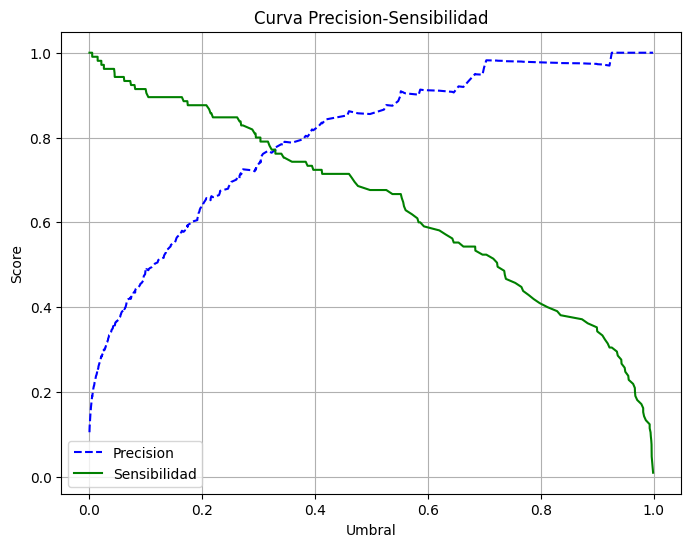

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)


plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
plt.plot(thresholds, recall[:-1], 'g-', label='Sensibilidad')
plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Curva Precision-Sensibilidad')
plt.legend()
plt.grid(True)
plt.show()

## Curva ROC

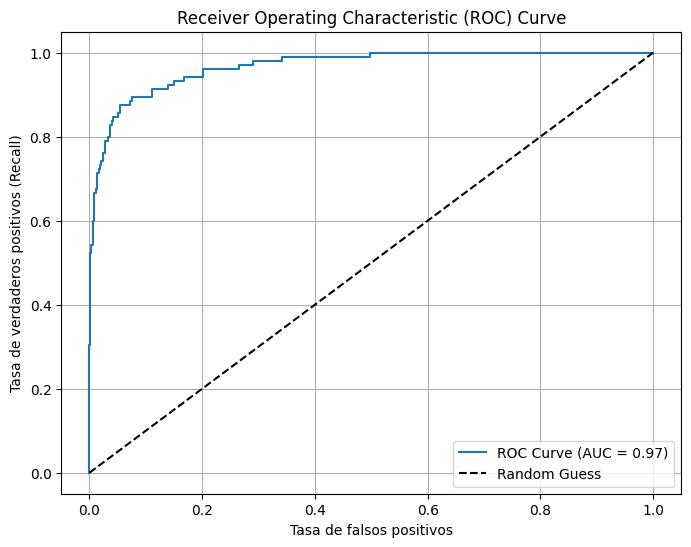

AUC: 0.97


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Grafica de la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Diagonal random guess line
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC: {auc:.2f}")

En este caso, un AUC de 0.97 es muy alto, lo que sugiere que el modelo de regresión logística está funcionando muy bien para distinguir entre las dos clases (Personal.Loan 0 y 1). El hecho de que la curva esté cercana a la esquina superior izquierda del gráfico confirma visualmente este buen desempeño.